# LEVEL-3

### TASK 1: Restaurant Reviews

In [1]:
"""
LEVEL 3 - TASK 1: Restaurant Reviews
NOTE: This dataset has no raw review-text column, so 'Rating text'
(Excellent/Very Good/Good/Average/Poor) is used as a proxy for
sentiment. If you obtain a file with actual review text, swap it
into the 'review_col' section below for genuine keyword extraction.
"""

import pandas as pd

# Load dataset
df = pd.read_csv('Dataset.csv')

review_col = None
for candidate in ['Review', 'Review Text', 'Reviews']:
    if candidate in df.columns:
        review_col = candidate
        break

if review_col:
    # ---- Genuine review-text analysis (runs only if such a column exists) ----
    from collections import Counter
    import re

    df['Review Length'] = df[review_col].astype(str).apply(len)

    positive_reviews = df[df['Aggregate rating'] >= 4][review_col].astype(str)
    negative_reviews = df[df['Aggregate rating'] <= 2][review_col].astype(str)

    def top_words(series, n=15):
        stopwords = {'the','a','an','and','is','was','it','to','of','for','in','this',
                     'i','we','my','very','with','on','at','were','are','food','place'}
        words = re.findall(r'[a-z]+', ' '.join(series).lower())
        words = [w for w in words if w not in stopwords and len(w) > 2]
        return Counter(words).most_common(n)

    print("Top positive keywords:", top_words(positive_reviews))
    print("Top negative keywords:", top_words(negative_reviews))
    print("\nCorrelation between review length and rating:")
    print(df[['Review Length', 'Aggregate rating']].corr())

else:
    # ---- Proxy analysis using Rating text (what this dataset actually has) ----
    print("No raw review-text column found — using 'Rating text' as a proxy.\n")

    rating_text_counts = df['Rating text'].str.lower().value_counts()
    print("Distribution of Rating text categories (proxy for sentiment keywords):")
    print(rating_text_counts)

    pos_count = df[df['Rating text'].str.lower().isin(['excellent', 'very good', 'good'])].shape[0]
    neg_count = df[df['Rating text'].str.lower().isin(['poor', 'average'])].shape[0]
    print(f"\nPositive-leaning restaurants (Good/Very Good/Excellent): {pos_count}")
    print(f"Negative-leaning restaurants (Average/Poor): {neg_count}")

    # Proxy for "review length" -> length of the Cuisines description
    df['Cuisines Text Length'] = df['Cuisines'].fillna('').astype(str).apply(len)
    corr = df['Cuisines Text Length'].corr(df['Aggregate rating'])
    print(f"\nCorrelation between cuisine-description length and rating (proxy): {corr:.3f}")

No raw review-text column found — using 'Rating text' as a proxy.

Distribution of Rating text categories (proxy for sentiment keywords):
Rating text
average      3737
not rated    2148
good         2100
very good    1079
excellent     301
poor          186
Name: count, dtype: int64

Positive-leaning restaurants (Good/Very Good/Excellent): 3480
Negative-leaning restaurants (Average/Poor): 3923

Correlation between cuisine-description length and rating (proxy): 0.194


### TASK 2: Votes Analysis

Top 5 restaurants with HIGHEST number of votes:
          Restaurant Name      City  Votes  Aggregate rating
                     Toit Bangalore  10934               4.8
                 Truffles Bangalore   9667               4.7
         Hauz Khas Social New Delhi   7931               4.3
                Peter Cat   Kolkata   7574               4.3
AB's - Absolute Barbecues Bangalore   6907               4.6

Top 5 restaurants with LOWEST number of votes:
   Restaurant Name       City  Votes  Aggregate rating
  Cantinho da Gula S��o Paulo      0               0.0
     The Chaiwalas  Faridabad      0               0.0
Fusion Food Corner  Faridabad      0               0.0
     Punjabi Rasoi  Faridabad      0               0.0
     Baskin Robbin  Faridabad      0               0.0

Correlation between Votes and Aggregate Rating: 0.3137
Interpretation: moderate positive relationship


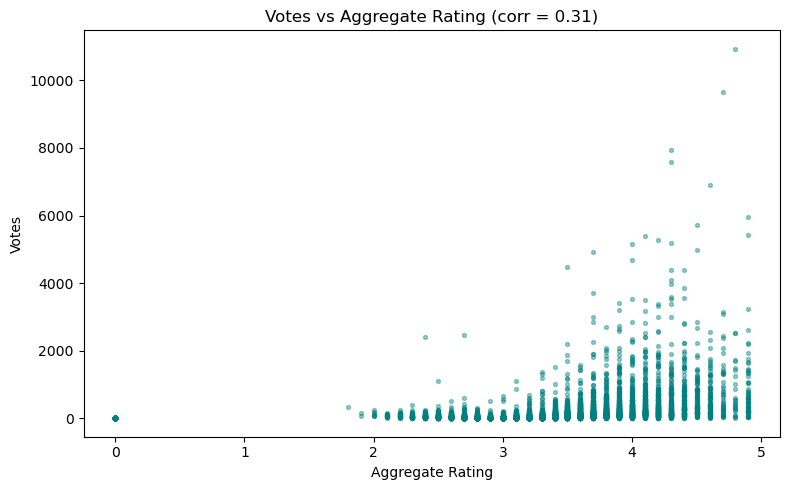


Chart saved as: level3_task2_votes_vs_rating.png


In [1]:
"""
LEVEL 3 - TASK 2: Votes Analysis
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Dataset.csv')

# ------------------------------------------------------------
# 1. Identify restaurants with highest and lowest votes
# ------------------------------------------------------------
top_voted = df.nlargest(5, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']]
print("Top 5 restaurants with HIGHEST number of votes:")
print(top_voted.to_string(index=False))

lowest_voted = df.nsmallest(5, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']]
print("\nTop 5 restaurants with LOWEST number of votes:")
print(lowest_voted.to_string(index=False))

# ------------------------------------------------------------
# 2. Correlation between votes and rating
# ------------------------------------------------------------
correlation = df['Votes'].corr(df['Aggregate rating'])
print(f"\nCorrelation between Votes and Aggregate Rating: {correlation:.4f}")

if correlation > 0.3:
    strength = "moderate positive"
elif correlation > 0:
    strength = "weak positive"
elif correlation > -0.3:
    strength = "weak negative"
else:
    strength = "moderate/strong negative"
print(f"Interpretation: {strength} relationship")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(df['Aggregate rating'], df['Votes'], s=8, alpha=0.4, c='teal')
plt.title(f'Votes vs Aggregate Rating (corr = {correlation:.2f})')
plt.xlabel('Aggregate Rating')
plt.ylabel('Votes')
plt.tight_layout()
plt.savefig('level3_task2_votes_vs_rating.png', dpi=150)
plt.show()

print("\nChart saved as: level3_task2_votes_vs_rating.png")

### TASK 3: Price Range vs. Online Delivery and Table Booking

% Online delivery availability by Price range:
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04

% Table booking availability by Price range:
Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76


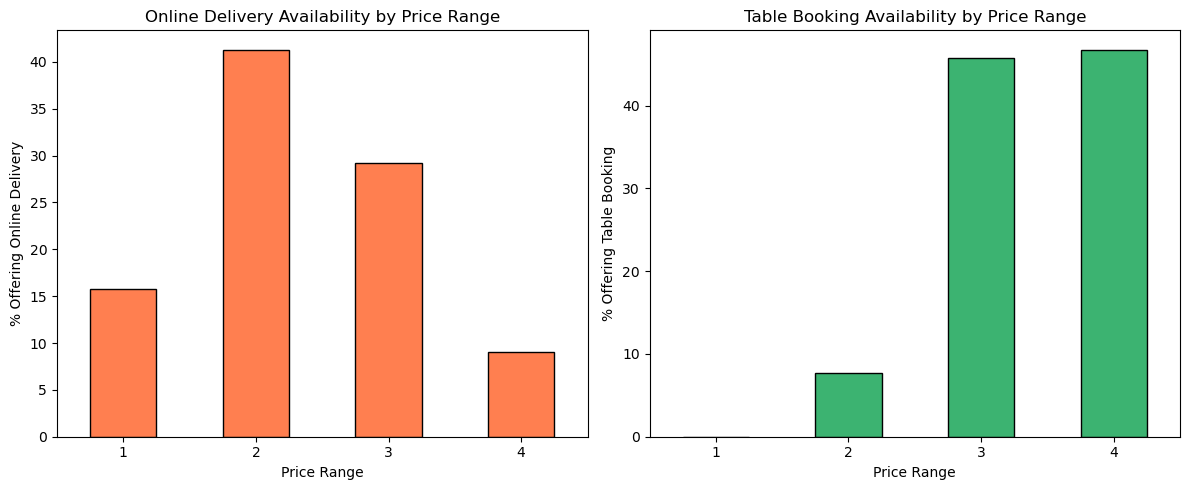


Chart saved as: level3_task3_price_vs_services.png

Online delivery — Price range 1: 15.8% | Price range 4: 9.0%
Table booking   — Price range 1: 0.0% | Price range 4: 46.8%


In [2]:
"""
LEVEL 3 - TASK 3: Price Range vs. Online Delivery and Table Booking
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Dataset.csv')

# ------------------------------------------------------------
# 1. Relationship between price range and service availability
# ------------------------------------------------------------
delivery_by_price = pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100
print("% Online delivery availability by Price range:")
print(delivery_by_price.round(2))

booking_by_price = pd.crosstab(df['Price range'], df['Has Table booking'], normalize='index') * 100
print("\n% Table booking availability by Price range:")
print(booking_by_price.round(2))

# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

delivery_by_price['Yes'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Online Delivery Availability by Price Range')
axes[0].set_ylabel('% Offering Online Delivery')
axes[0].set_xlabel('Price Range')
axes[0].tick_params(axis='x', rotation=0)

booking_by_price['Yes'].plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Table Booking Availability by Price Range')
axes[1].set_ylabel('% Offering Table Booking')
axes[1].set_xlabel('Price Range')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('level3_task3_price_vs_services.png', dpi=150)
plt.show()

print("\nChart saved as: level3_task3_price_vs_services.png")

# ------------------------------------------------------------
# 3. Determine if higher-priced restaurants offer these more
# ------------------------------------------------------------
lower_priced_delivery = delivery_by_price['Yes'].iloc[0]
higher_priced_delivery = delivery_by_price['Yes'].iloc[-1]
lower_priced_booking = booking_by_price['Yes'].iloc[0]
higher_priced_booking = booking_by_price['Yes'].iloc[-1]

print(f"\nOnline delivery — Price range 1: {lower_priced_delivery:.1f}% | Price range 4: {higher_priced_delivery:.1f}%")
print(f"Table booking   — Price range 1: {lower_priced_booking:.1f}% | Price range 4: {higher_priced_booking:.1f}%")